# MNIST Dense Neural Network (Modular Version, pre-submission)

This notebook trains a simple fully-connected neural network on MNIST,
but the core code is factorized into `.py` modules:

- `data.py` for data loading and splits
- `model.py` for hyperparameters and the `DNN` architecture
- `train_eval.py` for training and evaluation loops
- `plots.py` for learning curves and plots of the inputs
- `mnist_activations` for showing what is happening inside the DNN

The notebook contains only comments and library calls.
It will run, but should not be submitted in this form.
It provides both a baseline dnn system and an extended system using dropout.


In [1]:
%load_ext autoreload
%autoreload 2

import torch

from confusions import evaluate_and_report
from data import load_mnist_normalized, split_train_dev_test, make_dataloaders
from model import HyperParams, DNN
from train_eval import train_model, evaluate_model
from plots import plot_example_digits, plot_learning_curves
from mnist_activations import visualize_activations_on_loader, visualize_activations_by_label


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load and normalize the MNIST data

We:
1. Download MNIST via `fetch_openml`
2. Scale the pixel values from `[0, 255]` to approximately `[-1, 1]`
3. Return the inputs and labels as NumPy arrays.


In [3]:
X, y = load_mnist_normalized()
print("Data shape:", X.shape)
print("Label shape:", y.shape)
print("Label range:", y.min(), "to", y.max())


Data shape: (70000, 784)
Label shape: (70000,)
Label range: 0 to 9


## 2. Visualize a few example digits

We plot one example of each digit (0–9) to verify the data looks as expected.

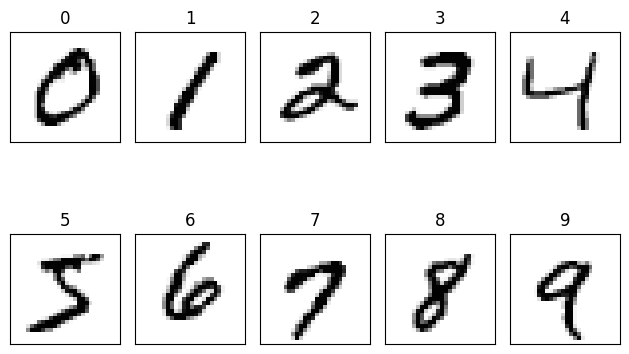

In [4]:
plot_example_digits(X, y)

## 3. Train / dev / test split and DataLoaders

- First, we follow the original dataset's convention: first 60,000 examples for train+dev, last 10,000 for test.
- Then we perform a stratified split of the training portion into:
  - a training set (90% of the first 60k)
  - a dev set (10% of the first 60k)

We need to provide the model configuration now, because the training batch size is needed by the `DataLoader`s that we are going to use to make the data available to PyTorch.


Finally, we wrap these arrays in PyTorch `Dataset`s and `DataLoader`s.


In [5]:
(X_train, y_train), (X_dev, y_dev), (X_test, y_test) = split_train_dev_test(X, y)

config = HyperParams(
    input_dim=X_train.shape[1],
    num_hid1_units=300,
    num_hid2_units=100,
    num_classes=10,
    lr=0.01,
    num_epochs=20,
    batch_size=64,
)

train_loader, dev_loader, test_loader = make_dataloaders(
    X_train,
    y_train,
    X_dev,
    y_dev,
    X_test,
    y_test,
    batch_size=config.batch_size,
    test_batch_size=16,
)

print("Train set:", X_train.shape)
print("Dev set:  ", X_dev.shape)
print("Test set: ", X_test.shape)


Train set: (54000, 784)
Dev set:   (6000, 784)
Test set:  (10000, 784)


## 4. Define the model and training setup

We instantiate:

- a `HyperParams` configuration object
- the `DNN` model using that configuration
- the training routine will create an SGD optimizer and CrossEntropy loss.


In [6]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
print("Using device:", device)

model = DNN(config)


Using device: mps


## 5. Train the model

We run the main training loop for `config.num_epochs`, tracking:

- average training loss and accuracy per epoch
- dev loss and accuracy per epoch


In [7]:
tr_losses, tr_accs, dev_losses, dev_accs = train_model(
    model=model,
    train_loader=train_loader,
    dev_loader=dev_loader,
    num_epochs=config.num_epochs,
    lr=config.lr,
    device=device,
)


Epoch 1/20 - Train loss 0.4756, acc 0.8562 - Dev loss 0.3012, acc 0.9053
Epoch 2/20 - Train loss 0.2615, acc 0.9224 - Dev loss 0.2363, acc 0.9317
Epoch 3/20 - Train loss 0.2117, acc 0.9382 - Dev loss 0.2021, acc 0.9385
Epoch 4/20 - Train loss 0.1813, acc 0.9479 - Dev loss 0.1772, acc 0.9457
Epoch 5/20 - Train loss 0.1594, acc 0.9540 - Dev loss 0.1654, acc 0.9493
Epoch 6/20 - Train loss 0.1428, acc 0.9589 - Dev loss 0.1508, acc 0.9533
Epoch 7/20 - Train loss 0.1286, acc 0.9633 - Dev loss 0.1505, acc 0.9533
Epoch 8/20 - Train loss 0.1175, acc 0.9659 - Dev loss 0.1384, acc 0.9558
Epoch 9/20 - Train loss 0.1077, acc 0.9693 - Dev loss 0.1247, acc 0.9618
Epoch 10/20 - Train loss 0.0998, acc 0.9719 - Dev loss 0.1228, acc 0.9632
Epoch 11/20 - Train loss 0.0928, acc 0.9737 - Dev loss 0.1175, acc 0.9642
Epoch 12/20 - Train loss 0.0865, acc 0.9753 - Dev loss 0.1118, acc 0.9655
Epoch 13/20 - Train loss 0.0804, acc 0.9772 - Dev loss 0.1095, acc 0.9673
Epoch 14/20 - Train loss 0.0758, acc 0.9784 - D

## 6. Plot learning curves

We visualize loss and accuracy for both training and dev sets
to see whether the model is overfitting or underfitting.


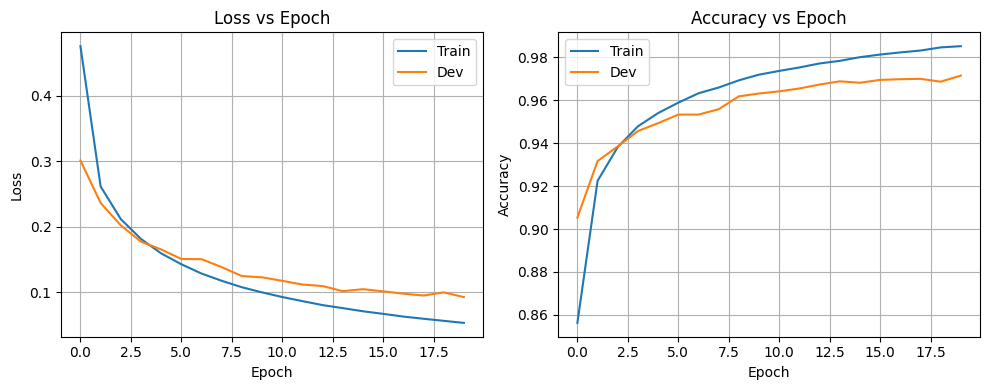

In [8]:
plot_learning_curves(tr_losses, tr_accs, dev_losses, dev_accs)

Q1) Discuss whether this baseline system overfits, underfits or reasonably fits the validation data.

Sample answer: This looks OK. At 20 epochs the model is slightly underfitting the validation data. The gap between the training and the testing data seems to be increasing, but fairly slowly. Fit to the validation data is still probably improving. Overall, reasonably fitting seems right.



Now we make a visualization of some of the activations, layer-by-layer.

The point of this is to give you some tools to do with visualization.

- The DNN sees a flat array of 768 numbers and doesn't know what is next to what in the spatial layout. It connects the layers any way that it wants, so there probably isn't going to be very many visually interesting connections between one layer and the next. The most useful things to visualize are the average **activations** of each layer. That's what we do here.

Layers captured: ['fc1', 'fc2', 'fc3']


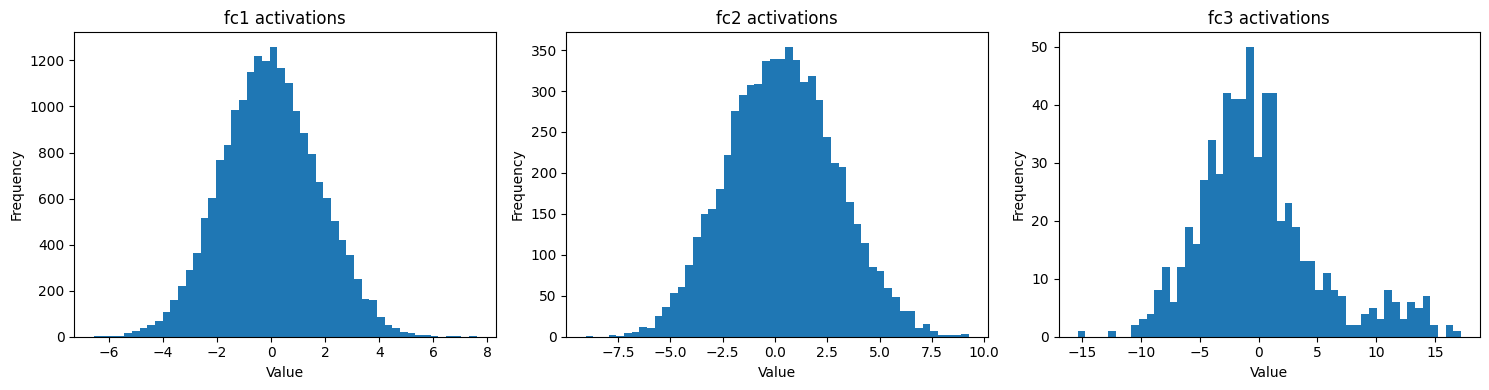

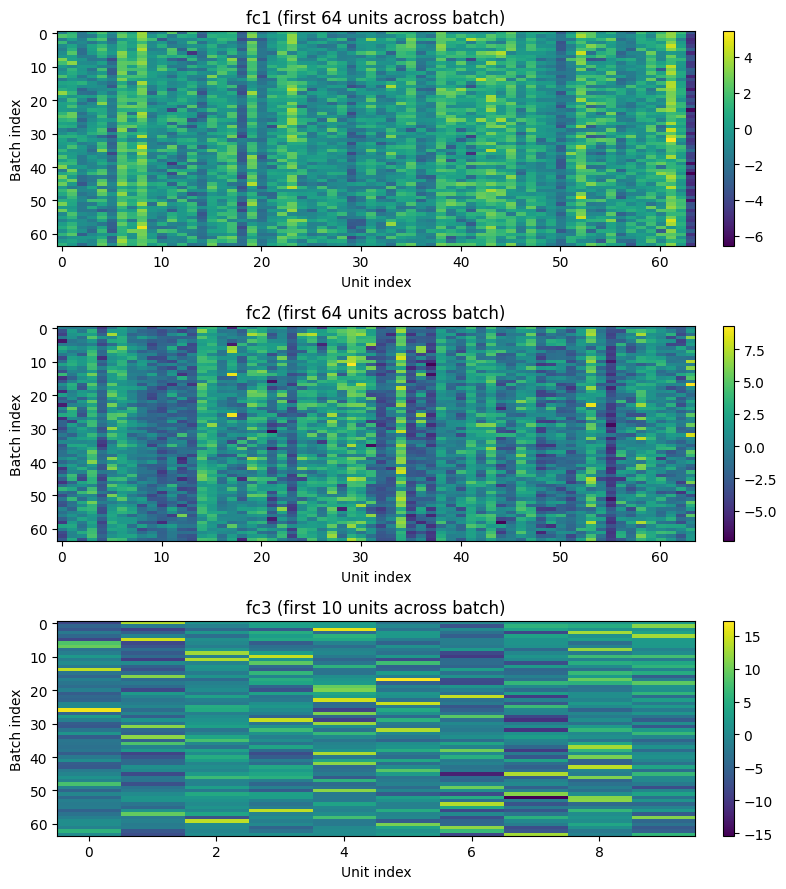

In [9]:
visualize_activations_on_loader(model, dev_loader, device=device, max_batches=1)


It's useful to average the activations not by batch, as above, but according to the identity of the correct digit. This is what we do next. The first two layers each have > 64 neurons, and we are only showing 64, so there is not that much to see. The final layer has just 10 neurons, all shown, and we can easily see that the strongest activations are associated with the desired answers.

Layers captured: ['fc1', 'fc2', 'fc3']
Total examples sampled: 192


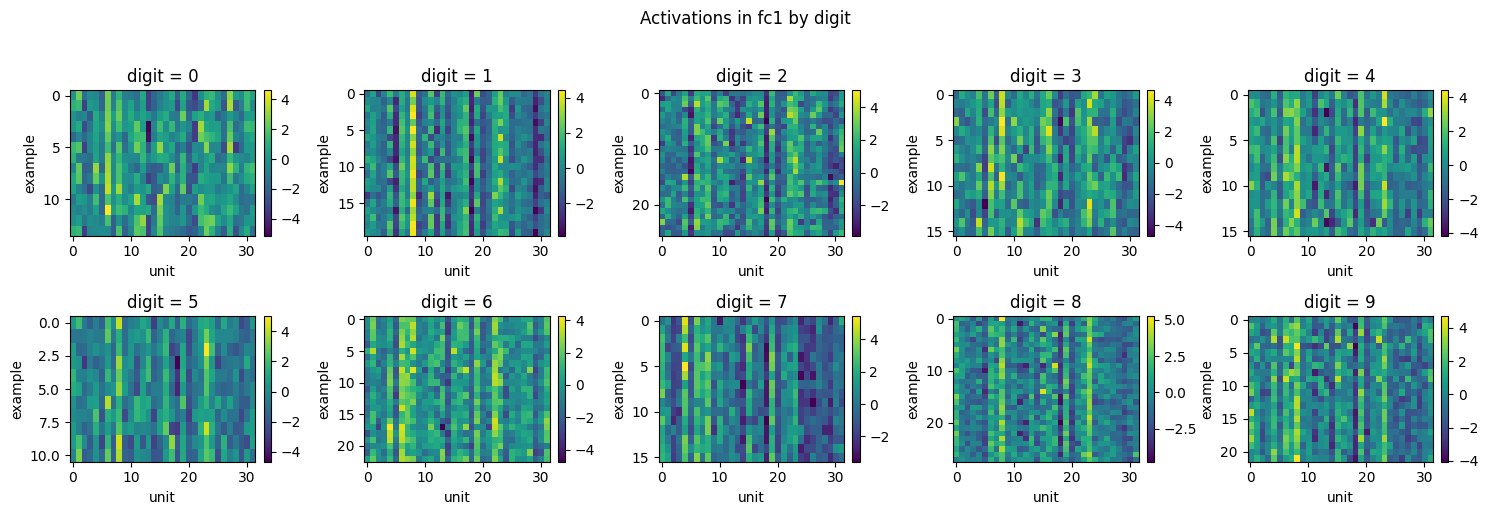

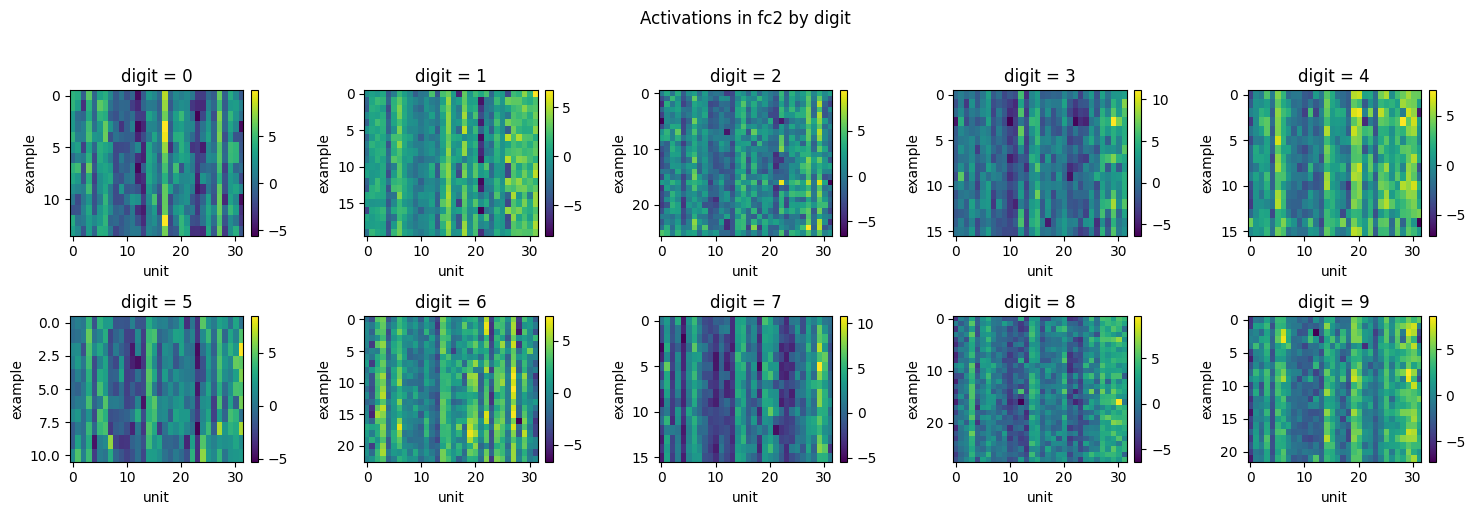

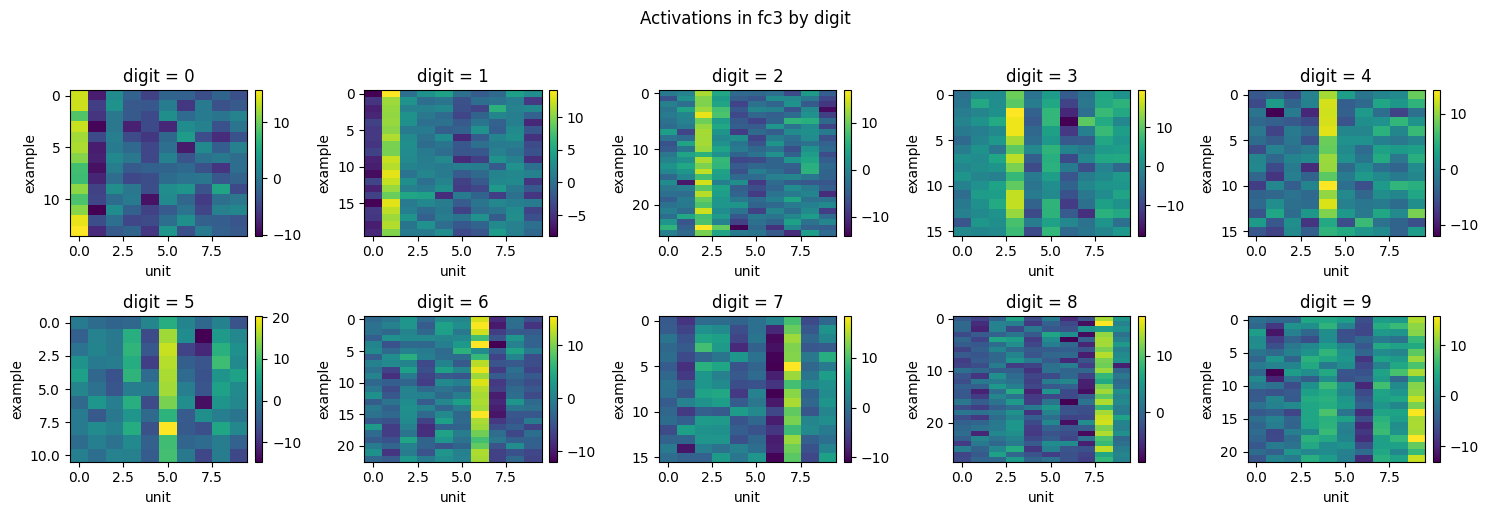

In [10]:
visualize_activations_by_label(model, dev_loader, device=device)

# Confusion matrix
Display a confusion matrix and a classification report showing how the classification looks on the development set. The classification report gives accuracy, as requested in the assignment.


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0    0.97961   0.98061   0.98011       980
           1    0.98598   0.99119   0.98858      1135
           2    0.94315   0.98062   0.96152      1032
           3    0.95652   0.98020   0.96822      1010
           4    0.97636   0.96741   0.97187       982
           5    0.97717   0.95964   0.96833       892
           6    0.97597   0.97495   0.97546       958
           7    0.97448   0.96595   0.97020      1028
           8    0.97906   0.95996   0.96941       974
           9    0.97273   0.95441   0.96348      1009

    accuracy                        0.97190     10000
   macro avg    0.97210   0.97149   0.97172     10000
weighted avg    0.97208   0.97190   0.97191     10000



<Figure size 800x800 with 0 Axes>

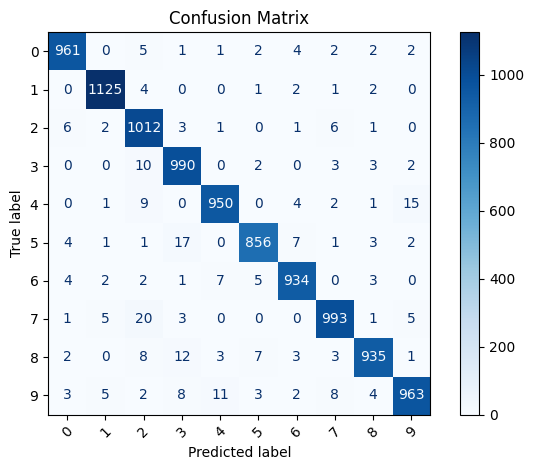

In [11]:
evaluate_and_report(model, test_loader)

# End of part 1



# Start of part 2

Dropout after each hidden layer.

Compare dropout rates of 0.25, 0.5, and 0.75. The code for this is already present in `model.py`. We just weren't using it yet.



Epoch 1/50 - Train loss 0.8281, acc 0.7353 - Dev loss 0.3422, acc 0.8982
Epoch 2/50 - Train loss 0.4424, acc 0.8637 - Dev loss 0.2603, acc 0.9207
Epoch 3/50 - Train loss 0.3581, acc 0.8914 - Dev loss 0.2231, acc 0.9308
Epoch 4/50 - Train loss 0.3104, acc 0.9059 - Dev loss 0.1959, acc 0.9392
Epoch 5/50 - Train loss 0.2781, acc 0.9168 - Dev loss 0.1776, acc 0.9445
Epoch 6/50 - Train loss 0.2569, acc 0.9228 - Dev loss 0.1675, acc 0.9470
Epoch 7/50 - Train loss 0.2349, acc 0.9301 - Dev loss 0.1582, acc 0.9517
Epoch 8/50 - Train loss 0.2237, acc 0.9323 - Dev loss 0.1541, acc 0.9518
Epoch 9/50 - Train loss 0.2112, acc 0.9377 - Dev loss 0.1429, acc 0.9542
Epoch 10/50 - Train loss 0.1963, acc 0.9409 - Dev loss 0.1364, acc 0.9578
Epoch 11/50 - Train loss 0.1910, acc 0.9434 - Dev loss 0.1298, acc 0.9592
Epoch 12/50 - Train loss 0.1774, acc 0.9469 - Dev loss 0.1299, acc 0.9583
Epoch 13/50 - Train loss 0.1724, acc 0.9484 - Dev loss 0.1211, acc 0.9620
Epoch 14/50 - Train loss 0.1661, acc 0.9496 - D

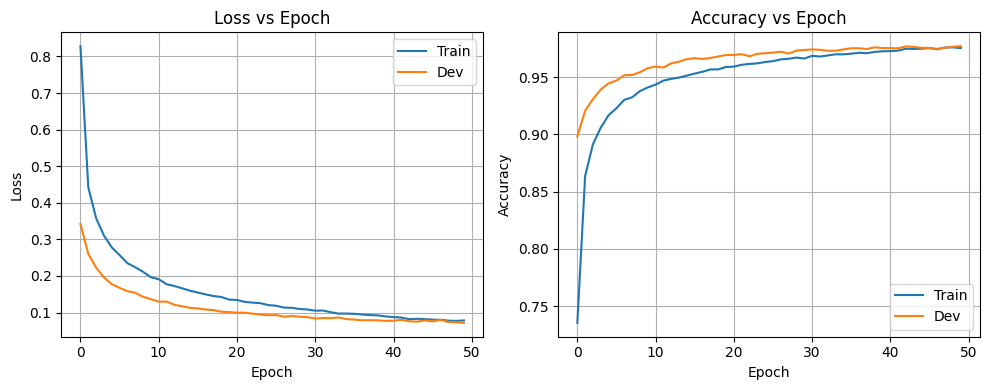

In [12]:
config = HyperParams(
    input_dim=X_train.shape[1],
    num_hid1_units=300,
    num_hid2_units=100,
    num_classes=10,
    lr=0.01,
    num_epochs=50,
    batch_size=64,
    dropout_rate=0.25,
    use_dropout=True,
)
model2 = DNN(config)
tr_losses, tr_accs, dev_losses, dev_accs = train_model(
    model=model2,
    train_loader=train_loader,
    dev_loader=dev_loader,
    num_epochs=config.num_epochs,
    lr=config.lr,
    device=device,
)

# re-use loaders, because batch size did not change.
plot_learning_curves(tr_losses, tr_accs, dev_losses, dev_accs)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0    0.97879   0.98878   0.98376       980
           1    0.98422   0.98943   0.98682      1135
           2    0.97485   0.97674   0.97580      1032
           3    0.97143   0.97624   0.97383      1010
           4    0.97467   0.97963   0.97715       982
           5    0.97738   0.96861   0.97297       892
           6    0.97704   0.97704   0.97704       958
           7    0.96718   0.97471   0.97093      1028
           8    0.97921   0.96715   0.97314       974
           9    0.97986   0.96432   0.97203      1009

    accuracy                        0.97650     10000
   macro avg    0.97646   0.97626   0.97635     10000
weighted avg    0.97651   0.97650   0.97649     10000



<Figure size 800x800 with 0 Axes>

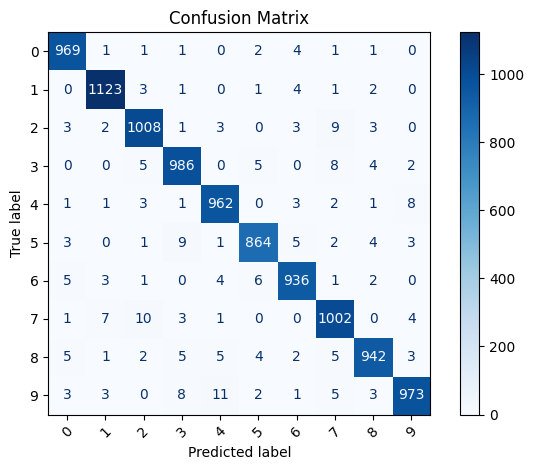

In [12]:
evaluate_and_report(model2, test_loader)

Q2.1: What happened?

With dropout=0.25, training loss starts higher than validation loss, and training accuracy lower, because we are not using all the neurons on the training data. Convergence is slower than baseline, but eventual test accuracy just a little better. But training and validation converge. We seem to get a modest improvement from this level of dropout.

Epoch 1/100 - Train loss 1.3318, acc 0.5669 - Dev loss 0.4718, acc 0.8737
Epoch 2/100 - Train loss 0.7228, acc 0.7724 - Dev loss 0.3517, acc 0.9040
Epoch 3/100 - Train loss 0.5906, acc 0.8195 - Dev loss 0.3019, acc 0.9135
Epoch 4/100 - Train loss 0.5148, acc 0.8447 - Dev loss 0.2705, acc 0.9230
Epoch 5/100 - Train loss 0.4644, acc 0.8614 - Dev loss 0.2526, acc 0.9245
Epoch 6/100 - Train loss 0.4273, acc 0.8750 - Dev loss 0.2353, acc 0.9317
Epoch 7/100 - Train loss 0.3971, acc 0.8844 - Dev loss 0.2217, acc 0.9342
Epoch 8/100 - Train loss 0.3751, acc 0.8918 - Dev loss 0.2048, acc 0.9408
Epoch 9/100 - Train loss 0.3628, acc 0.8929 - Dev loss 0.2012, acc 0.9395
Epoch 10/100 - Train loss 0.3419, acc 0.9024 - Dev loss 0.1974, acc 0.9415
Epoch 11/100 - Train loss 0.3286, acc 0.9068 - Dev loss 0.1880, acc 0.9433
Epoch 12/100 - Train loss 0.3141, acc 0.9093 - Dev loss 0.1845, acc 0.9437
Epoch 13/100 - Train loss 0.3082, acc 0.9111 - Dev loss 0.1752, acc 0.9465
Epoch 14/100 - Train loss 0.2965, 

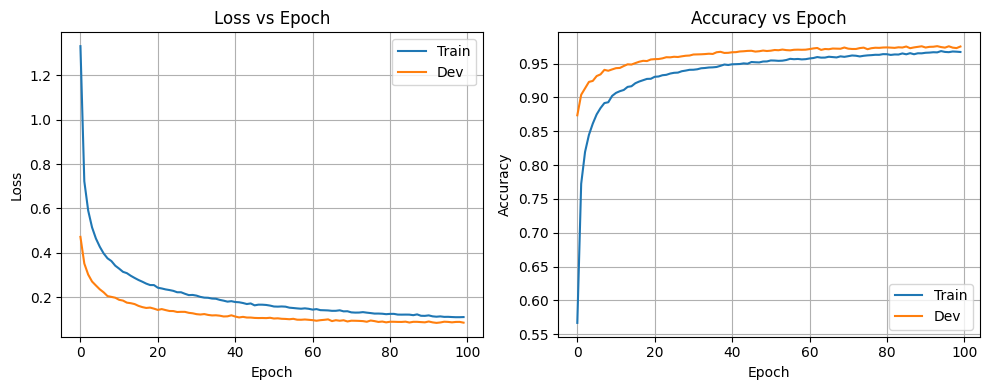

In [14]:
config = HyperParams(
    input_dim=X_train.shape[1],
    num_hid1_units=300,
    num_hid2_units=100,
    num_classes=10,
    lr=0.01,
    num_epochs=100,
    batch_size=64,
    dropout_rate=0.50,
    use_dropout=True,
)
model3 = DNN(config)
tr_losses, tr_accs, dev_losses, dev_accs = train_model(
    model=model3,
    train_loader=train_loader,
    dev_loader=dev_loader,
    num_epochs=config.num_epochs,
    lr=config.lr,
    device=device,
)
plot_learning_curves(tr_losses, tr_accs, dev_losses, dev_accs)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0    0.97986   0.99286   0.98632       980
           1    0.98511   0.99119   0.98814      1135
           2    0.97295   0.97578   0.97436      1032
           3    0.97146   0.97723   0.97433      1010
           4    0.97653   0.97454   0.97554       982
           5    0.98088   0.97758   0.97923       892
           6    0.98115   0.97808   0.97961       958
           7    0.96893   0.97082   0.96987      1028
           8    0.97815   0.96509   0.97158       974
           9    0.97497   0.96531   0.97012      1009

    accuracy                        0.97700     10000
   macro avg    0.97700   0.97685   0.97691     10000
weighted avg    0.97700   0.97700   0.97699     10000



<Figure size 800x800 with 0 Axes>

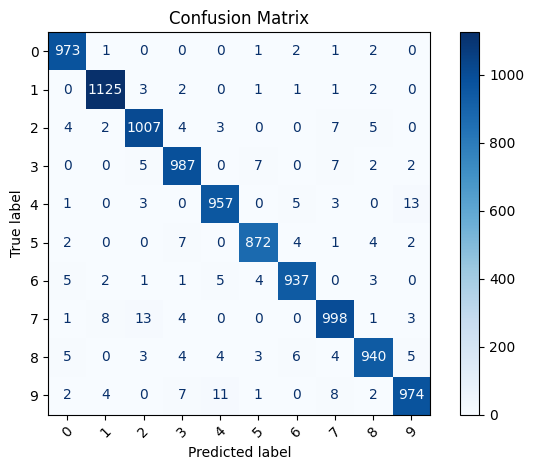

In [15]:
evaluate_and_report(model3, test_loader)

# Comments on dropout = 0.50

Convergence is even slower than with dropout 0.25, we needed 100 epochs. Performance on test data is essentially identical to the condition without dropout

Epoch 1/200 - Train loss 2.2307, acc 0.2239 - Dev loss 1.6142, acc 0.6392
Epoch 2/200 - Train loss 1.7711, acc 0.3759 - Dev loss 1.2289, acc 0.7890
Epoch 3/200 - Train loss 1.5360, acc 0.4723 - Dev loss 0.9771, acc 0.8472
Epoch 4/200 - Train loss 1.3782, acc 0.5326 - Dev loss 0.8019, acc 0.8675
Epoch 5/200 - Train loss 1.2877, acc 0.5691 - Dev loss 0.7492, acc 0.8683
Epoch 6/200 - Train loss 1.2050, acc 0.6041 - Dev loss 0.6465, acc 0.8813
Epoch 7/200 - Train loss 1.1260, acc 0.6328 - Dev loss 0.6241, acc 0.8853
Epoch 8/200 - Train loss 1.0647, acc 0.6566 - Dev loss 0.5829, acc 0.8850
Epoch 9/200 - Train loss 1.0172, acc 0.6727 - Dev loss 0.5281, acc 0.8903
Epoch 10/200 - Train loss 0.9896, acc 0.6865 - Dev loss 0.4895, acc 0.8963
Epoch 11/200 - Train loss 0.9565, acc 0.6965 - Dev loss 0.4686, acc 0.8993
Epoch 12/200 - Train loss 0.9282, acc 0.7092 - Dev loss 0.4632, acc 0.9013
Epoch 13/200 - Train loss 0.9063, acc 0.7155 - Dev loss 0.4487, acc 0.8975
Epoch 14/200 - Train loss 0.8904, 

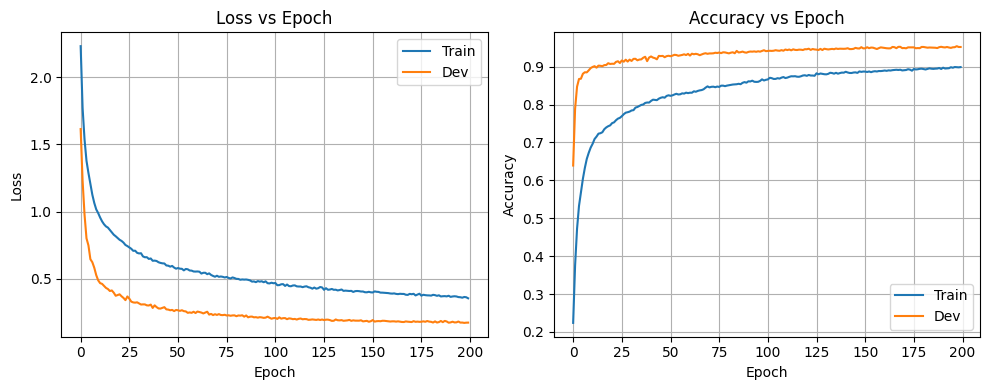

In [16]:
config = HyperParams(
    input_dim=X_train.shape[1],
    num_hid1_units=300,
    num_hid2_units=100,
    num_classes=10,
    lr=0.01,
    num_epochs=200,
    batch_size=64,
    dropout_rate=0.75,
    use_dropout=True,
)
model4 = DNN(config)
tr_losses, tr_accs, dev_losses, dev_accs = train_model(
    model=model4,
    train_loader=train_loader,
    dev_loader=dev_loader,
    num_epochs=config.num_epochs,
    lr=config.lr,
    device=device,
)
plot_learning_curves(tr_losses, tr_accs, dev_losses, dev_accs)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0    0.96607   0.98776   0.97679       980
           1    0.98062   0.98062   0.98062      1135
           2    0.95825   0.95640   0.95732      1032
           3    0.96967   0.94950   0.95948      1010
           4    0.92203   0.96334   0.94223       982
           5    0.94695   0.94058   0.94376       892
           6    0.96162   0.96764   0.96462       958
           7    0.95481   0.94553   0.95015      1028
           8    0.94742   0.94353   0.94547       974
           9    0.93776   0.91080   0.92408      1009

    accuracy                        0.95490     10000
   macro avg    0.95452   0.95457   0.95445     10000
weighted avg    0.95499   0.95490   0.95485     10000



<Figure size 800x800 with 0 Axes>

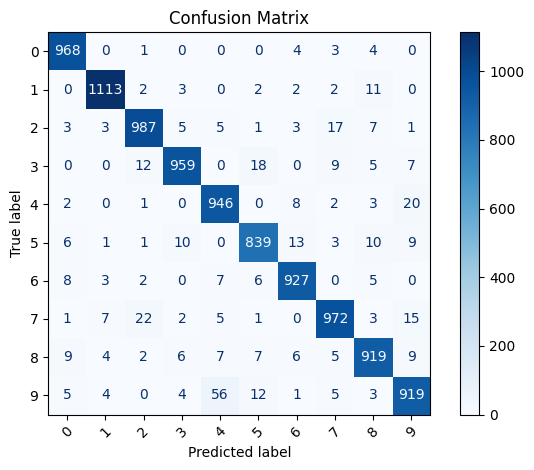

In [18]:
evaluate_and_report(model4, test_loader)

## Comments on dropout = 0.75

With dropout of 0.75, even after 200 epochs the model is not doing as well as baseline. This dropout value seems to be too high for the dataset and the architecture.